# Monte Carlo Engine

Prices options using four Monte Carlo methods and compares them against the Black-Scholes analytical benchmark.

**Methods implemented:**
- **Plain MC** - baseline GBM simulation, O(1/√N) convergence
- **Antithetic Variates** - mirrors each path with its negative; halves variance at no extra simulation cost
- **Control Variate** - uses BlackScholes price as a known anchor to remove correlated error; typically 80–95% variance reduction ATM
- **Quasi-MC (Sobol)** - replaces pseudo-random draws with low-discrepancy sequences; effective O(1/N) convergence in 1D

## 1. Imports & Path Setup

In [33]:
import sys, os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── PATH CONFIG ────────────────────────────────────────────────────────────────
PROJECT_ROOT = "."    # folder containing params.py, black_scholes.py, monte_carlo.py
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# ───────────────────────────────────────────────────────────────────────────────

from params import SharedParameters
from BlackScholes import bs_price
from MonteCarlo import (plainMC, antitheticMC, controlMC, quasiMC, convergence, compare_methods, MCresult)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

COLORS = {
    'bs': '#222222',
    'plain_mc': "#1978D7",
    'antithetic_mc': "#B91010",
    'control_variate': "#0AD36B",
    'quasi_mc': "#953BDF",
    'market': "#F08D29",
    'spot': '#888888',
}

## 2. List Available Snapshots

In [34]:
def list_snapshots(data_dir=DATA_DIR):
    if not os.path.exists(data_dir):
        print(f"Data directory not found: {os.path.abspath(data_dir)}")
        return []
    meta_files = sorted(f for f in os.listdir(data_dir) if f.endswith("_meta.json"))
    if not meta_files:
        print("No snapshots found. Run OptionsData.ipynb first.")
        return []
    slugs = []
    print(f"{'#':<3}  {'Slug':<48}  {'Ticker':<6}  {'Expiry':<12}  "
          f"{'Spot':>7}  {'DTE':>5}  {'T':>6}  {'Calls':>6}  {'Puts':>5}")
    print("─" * 115)
    for i, mf in enumerate(meta_files):
        with open(os.path.join(data_dir, mf)) as f:
            m = json.load(f)
        slug = mf.replace("_meta.json", "")
        slugs.append(slug)
        print(f"{i:<3}  {slug:<48}  {m['ticker']:<6}  {m['expiry']:<12}  "
              f"${m['spot']:>6.2f}  {m.get('dte','?'):>5}  "
              f"{m['T']:>6.4f}  {m.get('n_calls','?'):>6}  {m.get('n_puts','?'):>5}")
    return slugs

available_slugs = list_snapshots()

#    Slug                                              Ticker  Expiry           Spot    DTE       T   Calls   Puts
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
0    MSFT_2026-07-10_20260602_0214                     MSFT    2026-07-10    $460.52     37  0.1014      38     27


## 3. Select Snapshot & Configure

In [35]:
# ── SNAPSHOT SELECTION ─────────────────────────────────────────────────────────
SLUG       = ""    # paste slug here, or leave empty to use SLUG_INDEX
SLUG_INDEX = 0    # index of snapshot to load (ignored if SLUG is set)

# ── MC CONFIGURATION ───────────────────────────────────────────────────────────
N_PATHS     = 200_000    # paths per method for the main pricing run
Q           = 0.0        # continuous dividend yield
SEED        = 42         # random seed for reproducibility

# Convergence study settings
N_CONV_MIN  = 100        # smallest N in convergence study
N_CONV_MAX  = 500_000    # largest N
N_CONV_PTS  = 20         # number of N values (log-spaced)
N_REPEATS   = 15         # independent trials per N (for error bars)
# ───────────────────────────────────────────────────────────────────────────────

if not SLUG:
    if not available_slugs:
        raise RuntimeError("No snapshots available. Run OptionsData.ipynb first.")
    SLUG = available_slugs[SLUG_INDEX]

# Load snapshot
with open(os.path.join(DATA_DIR, f"{SLUG}_meta.json")) as f:
    meta = json.load(f)

calls_mkt = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_calls.csv"))
puts_mkt  = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_puts.csv"))

S      = float(meta['spot'])
r      = float(meta['r'])
T      = float(meta['T'])
TICKER = meta['ticker']
EXPIRY = meta['expiry']
DTE    = meta.get('dte', round(T * 365))

# Load BS results if available (for comparison columns)
bs_calls_path = os.path.join(DATA_DIR, f"{SLUG}_bs_calls.csv")
bs_puts_path  = os.path.join(DATA_DIR, f"{SLUG}_bs_puts.csv")
bs_calls = pd.read_csv(bs_calls_path) if os.path.exists(bs_calls_path) else None
bs_puts  = pd.read_csv(bs_puts_path)  if os.path.exists(bs_puts_path)  else None

print(f"Snapshot  : {SLUG}")
print(f"Ticker    : {TICKER}  |  Expiry: {EXPIRY}  ({DTE} DTE)")
print(f"Spot      : ${S:.2f}  |  r: {r:.2%}  |  T: {T:.4f}y  |  q: {Q:.2%}")
print(f"Calls     : {len(calls_mkt)} liquid strikes")
print(f"Puts      : {len(puts_mkt)} liquid strikes")
print(f"BS results: {'loaded' if bs_calls is not None else 'not found. run BlackScholes.ipynb first for full comparison'}")
print(f"\nMC config : N={N_PATHS:,}  seed={SEED}  repeats={N_REPEATS}")

Snapshot  : MSFT_2026-07-10_20260602_0214
Ticker    : MSFT  |  Expiry: 2026-07-10  (37 DTE)
Spot      : $460.52  |  r: 3.60%  |  T: 0.1014y  |  q: 0.00%
Calls     : 38 liquid strikes
Puts      : 27 liquid strikes
BS results: loaded

MC config : N=200,000  seed=42  repeats=15


## 4. Single-Strike Deep Dive

Pick the ATM (or nearest) strike, run all four methods, and compare directly against BS. This is the clearest way to see what each method does.

In [36]:
# Find the call strike nearest to spot (ATM)
atm_row  = calls_mkt.iloc[(calls_mkt['strike'] - S).abs().argsort().iloc[0]]
K_atm    = float(atm_row['strike'])
mid_atm  = float(atm_row['mid'])
sigma_atm = float(atm_row['impliedVolatility'])

# Use yfinance IV as σ — same as BS notebook does
p_atm = SharedParameters(S=S, K=K_atm, r=r, sigma=sigma_atm, T=T)
bs_ref = bs_price(p_atm, 'call', q=Q)

print(f"ATM call selected")
print(f"  Strike      : ${K_atm:.2f}  (moneyness {K_atm/S:.4f})")
print(f"  Market mid  : ${mid_atm:.4f}")
print(f"  σ (yf IV)   : {sigma_atm:.2%}")
print(f"  BS price    : ${bs_ref:.4f}")
print()

methods = [
    ('plain_mc',        plainMC),
    ('antithetic_mc',   antitheticMC),
    ('control_variate', controlMC),
    ('quasi_mc',        quasiMC),
]

print(f"{'Method':<40}  {'Price':>9}  {'Stderr':>9}  {'|vs BS|':>9}  "
      f"{'|vs Mkt|':>9}  {'95% CI':>10}  {'Time':>12}")
print("─" * 130)

single_results = {}
print(f"{'Black-Scholes':40}  {bs_ref:>9.4f}  {'—':>9}  {'—':>9}  "
      f"{abs(bs_ref-mid_atm):>9.4f}  {'—':>22}")

for key, fn in methods:
    t0  = time.perf_counter()
    res = fn(p_atm, n_paths=N_PATHS, option_type='call', q=Q, seed=SEED)
    dt  = time.perf_counter() - t0
    err_bs  = abs(res.price - bs_ref)
    err_mkt = abs(res.price - mid_atm)
    single_results[key] = res
    print(f"{res.method:<40}  {res.price:>9.4f}  {res.stderr:>9.6f}  "
          f"{err_bs:>9.4f}  {err_mkt:>9.4f}  "
          f"[{res.ci_low:.4f}, {res.ci_high:.4f}]  {dt:>5.2f}s")

ATM call selected
  Strike      : $460.00  (moneyness 0.9989)
  Market mid  : $21.4500
  σ (yf IV)   : 36.91%
  BS price    : $22.6394

Method                                        Price     Stderr    |vs BS|   |vs Mkt|      95% CI          Time
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Black-Scholes                               22.6394          —          —     1.1894                       —
Plain Monte Carlo                           22.6725   0.077811     0.0331     1.2225  [22.5200, 22.8250]   0.01s
Antithetic Monte Carlo                      22.6885   0.041569     0.0491     1.2385  [22.6070, 22.7699]   0.01s
Control Variate Monte Carlo                 22.6849   0.036409     0.0456     1.2349  [22.6136, 22.7563]   0.01s
Quasi-Monte Carlo (Sobol, n=262,144)        22.6393   0.067565     0.0000     1.1893  [22.5069, 22.7718]   0.02s


## 5. Price All Liquid Strikes

Run all four MC methods across every liquid call and put strike in the snapshot.

In [37]:
def price_all_strikes(df, option_type, S, r, T, q, n_paths, seed):
    """
    Run all four MC methods on every strike in df.
    Uses yfinance IV for sigma (same convention as BS notebook).
    Returns a DataFrame with one row per strike.
    """
    records = []

    for _, row in df.iterrows():
        K        = float(row['strike'])
        mid      = float(row['mid'])
        sigma    = float(row['impliedVolatility'])
        moneyness = float(row.get('moneyness', K / S))

        if sigma <= 0:
            continue

        try:
            p      = SharedParameters(S=S, K=K, r=r, sigma=sigma, T=T)
            bs_ref = bs_price(p, option_type, q=q)

            res_plain = plainMC(p, n_paths, option_type, q, seed)
            res_anti  = antitheticMC(p, n_paths, option_type, q, seed)
            res_cv    = controlMC(p, n_paths, option_type, q, seed)
            res_qmc   = quasiMC(p, n_paths, option_type, q, seed)

            records.append({
                'strike'       : K,
                'moneyness'    : round(moneyness, 4),
                'market_mid'   : round(mid, 4),
                'sigma'        : round(sigma, 4),
                'bs_price'     : round(bs_ref, 4),
                # Plain MC
                'plain_price'  : round(res_plain.price, 4),
                'plain_stderr' : round(res_plain.stderr, 6),
                'plain_ci_lo'  : round(res_plain.ci_low, 4),
                'plain_ci_hi'  : round(res_plain.ci_high, 4),
                'plain_err_bs' : round(res_plain.price - bs_ref, 4),
                # Antithetic
                'anti_price'   : round(res_anti.price, 4),
                'anti_stderr'  : round(res_anti.stderr, 6),
                'anti_err_bs'  : round(res_anti.price - bs_ref, 4),
                # Control variate
                'cv_price'     : round(res_cv.price, 4),
                'cv_stderr'    : round(res_cv.stderr, 6),
                'cv_err_bs'    : round(res_cv.price - bs_ref, 4),
                # Quasi-MC
                'qmc_price'    : round(res_qmc.price, 4),
                'qmc_stderr'   : round(res_qmc.stderr, 6),
                'qmc_err_bs'   : round(res_qmc.price - bs_ref, 4),
            })

        except Exception as e:
            records.append({'strike': K, 'error': str(e)})

    return pd.DataFrame(records)


print(f"Pricing {len(calls_mkt)} call strikes with 4 methods × {N_PATHS:,} paths...")
t0 = time.perf_counter()
calls_mc = price_all_strikes(calls_mkt, 'call', S, r, T, Q, N_PATHS, SEED)
print(f"  Calls done in {time.perf_counter()-t0:.1f}s")

print(f"Pricing {len(puts_mkt)} put strikes...")
t0 = time.perf_counter()
puts_mc  = price_all_strikes(puts_mkt,  'put',  S, r, T, Q, N_PATHS, SEED)
print(f"  Puts done in {time.perf_counter()-t0:.1f}s")

print(f"\nComplete. {len(calls_mc)} calls, {len(puts_mc)} puts priced.")

Pricing 38 call strikes with 4 methods × 200,000 paths...
  Calls done in 1.1s
Pricing 27 put strikes...
  Puts done in 0.7s

Complete. 38 calls, 27 puts priced.


## 6. Results Tables

In [38]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 160)

price_cols = ['strike', 'moneyness', 'market_mid', 'bs_price',
              'plain_price', 'anti_price', 'cv_price', 'qmc_price']
error_cols = ['strike', 'moneyness',
              'plain_err_bs', 'anti_err_bs', 'cv_err_bs', 'qmc_err_bs',
              'plain_stderr', 'anti_stderr', 'cv_stderr', 'qmc_stderr']

for df, label in [(calls_mc, 'CALLS'), (puts_mc, 'PUTS')]:
    ok = df.dropna(subset=['plain_price'])
    print("=" * 80)
    print(f"{label} — {TICKER} | {EXPIRY} | Spot ${S:.2f}")
    print("=" * 80)
    print("\n── Prices ──")
    display(ok[price_cols])
    print("\n── Errors vs BS & Standard Errors ──")
    display(ok[error_cols])
    print()

CALLS — MSFT | 2026-07-10 | Spot $460.52

── Prices ──


,strike,moneyness,market_mid,bs_price,plain_price,anti_price,cv_price,qmc_price
0,350.0000,0.7600,112.8500,113.7706,113.7685,113.8411,113.7839,113.7706
1,355.0000,0.7709,108.0250,108.9443,108.9418,109.0136,108.9580,108.9442
2,370.0000,0.8034,93.4250,94.3548,94.3511,94.4186,94.3695,94.3548
3,380.0000,0.8252,83.8750,86.2300,86.2365,86.3059,86.2531,86.2299
4,385.0000,0.8360,79.1000,81.4772,81.4839,81.5508,81.5012,81.4771
5,390.0000,0.8469,74.4250,76.7709,76.7784,76.8426,76.7961,76.7709
6,395.0000,0.8577,69.7000,72.1108,72.1191,72.1803,72.1371,72.1108
7,400.0000,0.8686,65.1500,67.4979,67.5062,67.5651,67.5245,67.4979
8,405.0000,0.8794,60.6750,62.9788,62.9867,63.0440,63.0049,62.9787
9,410.0000,0.8903,56.2750,58.5540,58.5611,58.6175,58.5793,58.5539



── Errors vs BS & Standard Errors ──


,strike,moneyness,plain_err_bs,anti_err_bs,cv_err_bs,qmc_err_bs,plain_stderr,anti_stderr,cv_stderr,qmc_stderr
0,350.0000,0.7600,-0.0022,0.0705,0.0132,-0.0000,0.1820,0.0378,0.0189,0.1583
1,355.0000,0.7709,-0.0025,0.0693,0.0137,-0.0000,0.1767,0.0372,0.0195,0.1537
2,370.0000,0.8034,-0.0037,0.0638,0.0147,-0.0000,0.1580,0.0341,0.0203,0.1375
3,380.0000,0.8252,0.0065,0.0760,0.0232,-0.0000,0.1623,0.0421,0.0271,0.1412
4,385.0000,0.8360,0.0067,0.0736,0.0240,-0.0000,0.1557,0.0411,0.0274,0.1354
5,390.0000,0.8469,0.0074,0.0716,0.0252,-0.0000,0.1492,0.0403,0.0277,0.1298
6,395.0000,0.8577,0.0083,0.0695,0.0263,-0.0000,0.1430,0.0396,0.0281,0.1244
7,400.0000,0.8686,0.0083,0.0672,0.0266,-0.0000,0.1368,0.0390,0.0285,0.1190
8,405.0000,0.8794,0.0079,0.0652,0.0262,-0.0000,0.1310,0.0387,0.0290,0.1140
9,410.0000,0.8903,0.0071,0.0635,0.0253,-0.0000,0.1255,0.0386,0.0297,0.1091



PUTS — MSFT | 2026-07-10 | Spot $460.52

── Prices ──


,strike,moneyness,market_mid,bs_price,plain_price,anti_price,cv_price,qmc_price
0,350.0000,0.7600,0.5350,0.8056,0.8081,0.8206,0.8076,0.8056
1,355.0000,0.7709,0.4550,0.5847,0.5879,0.5973,0.5875,0.5847
2,360.0000,0.7817,0.6400,0.6931,0.6956,0.7065,0.6951,0.6930
3,365.0000,0.7926,0.7550,0.8033,0.8057,0.8177,0.8051,0.8032
4,370.0000,0.8034,0.8300,0.8359,0.8388,0.8508,0.8381,0.8359
5,375.0000,0.8143,1.0150,1.0419,1.0475,1.0593,1.0467,1.0419
6,380.0000,0.8252,1.1400,1.1187,1.1255,1.1368,1.1246,1.1187
7,385.0000,0.8360,1.3500,1.3171,1.3263,1.3370,1.3253,1.3171
8,390.0000,0.8469,1.5850,1.5337,1.5443,1.5553,1.5430,1.5337
9,395.0000,0.8577,1.9200,1.8590,1.8710,1.8828,1.8695,1.8590



── Errors vs BS & Standard Errors ──


,strike,moneyness,plain_err_bs,anti_err_bs,cv_err_bs,qmc_err_bs,plain_stderr,anti_stderr,cv_stderr,qmc_stderr
0,350.0000,0.7600,0.0025,0.0151,0.0020,-0.0000,0.0118,0.0083,0.0112,0.0103
1,355.0000,0.7709,0.0032,0.0126,0.0028,-0.0000,0.0096,0.0068,0.0091,0.0083
2,360.0000,0.7817,0.0026,0.0135,0.0021,-0.0000,0.0105,0.0074,0.0100,0.0091
3,365.0000,0.7926,0.0024,0.0145,0.0018,-0.0000,0.0113,0.0080,0.0107,0.0099
4,370.0000,0.8034,0.0029,0.0149,0.0022,-0.0000,0.0114,0.0081,0.0107,0.0100
5,375.0000,0.8143,0.0056,0.0174,0.0048,-0.0000,0.0129,0.0091,0.0120,0.0112
6,380.0000,0.8252,0.0068,0.0181,0.0059,-0.0000,0.0133,0.0093,0.0123,0.0116
7,385.0000,0.8360,0.0093,0.0200,0.0082,-0.0000,0.0145,0.0101,0.0132,0.0126
8,390.0000,0.8469,0.0105,0.0216,0.0093,-0.0000,0.0156,0.0109,0.0141,0.0136
9,395.0000,0.8577,0.0120,0.0238,0.0105,-0.0000,0.0174,0.0120,0.0154,0.0151


## 7. Summary: Variance Reduction Effectiveness

How much does each variance reduction technique actually help across all strikes?

In [39]:
def variance_reduction_summary(df, label):
    ok = df.dropna(subset=['plain_stderr'])
    if ok.empty:
        return

    plain_var = ok['plain_stderr'].mean()

    print(f"\n{'─'*65}")
    print(f"{label}  (N={N_PATHS:,} paths, {len(ok)} strikes)")
    print(f"{'─'*65}")
    print(f"  {'Method':<22}  {'Avg stderr':>11}  {'VR factor':>10}  {'Avg |err vs BS|':>16}")
    print(f"  {'─'*60}")

    for col_se, col_err, name in [
        ('plain_stderr', 'plain_err_bs', 'Plain MC'),
        ('anti_stderr',  'anti_err_bs',  'Antithetic'),
        ('cv_stderr',    'cv_err_bs',    'Control Variate'),
        ('qmc_stderr',   'qmc_err_bs',   'Quasi-MC (Sobol)'),
    ]:
        avg_se  = ok[col_se].mean()
        vr      = plain_var / avg_se if avg_se > 0 else float('inf')
        avg_err = ok[col_err].abs().mean()
        print(f"  {name:<22}  {avg_se:>11.6f}  {vr:>10.2f}×  {avg_err:>16.4f}")

variance_reduction_summary(calls_mc, f"CALLS — {TICKER} | {EXPIRY}")
variance_reduction_summary(puts_mc,  f"PUTS  — {TICKER} | {EXPIRY}")

print("""
VR factor = plain_stderr / method_stderr.
A factor of 3× means the method is as accurate as plain MC with 9× as many paths.
""")


─────────────────────────────────────────────────────────────────
CALLS — MSFT | 2026-07-10  (N=200,000 paths, 38 strikes)
─────────────────────────────────────────────────────────────────
  Method                   Avg stderr   VR factor   Avg |err vs BS|
  ────────────────────────────────────────────────────────────
  Plain MC                   0.088230        1.00×            0.0358
  Antithetic                 0.035043        2.52×            0.0561
  Control Variate            0.030542        2.89×            0.0470
  Quasi-MC (Sobol)           0.076593        1.15×            0.0000

─────────────────────────────────────────────────────────────────
PUTS  — MSFT | 2026-07-10  (N=200,000 paths, 27 strikes)
─────────────────────────────────────────────────────────────────
  Method                   Avg stderr   VR factor   Avg |err vs BS|
  ────────────────────────────────────────────────────────────
  Plain MC                   0.032599        1.00×            0.0259
  Antithetic 

## 8. Price vs Strike Dashboard

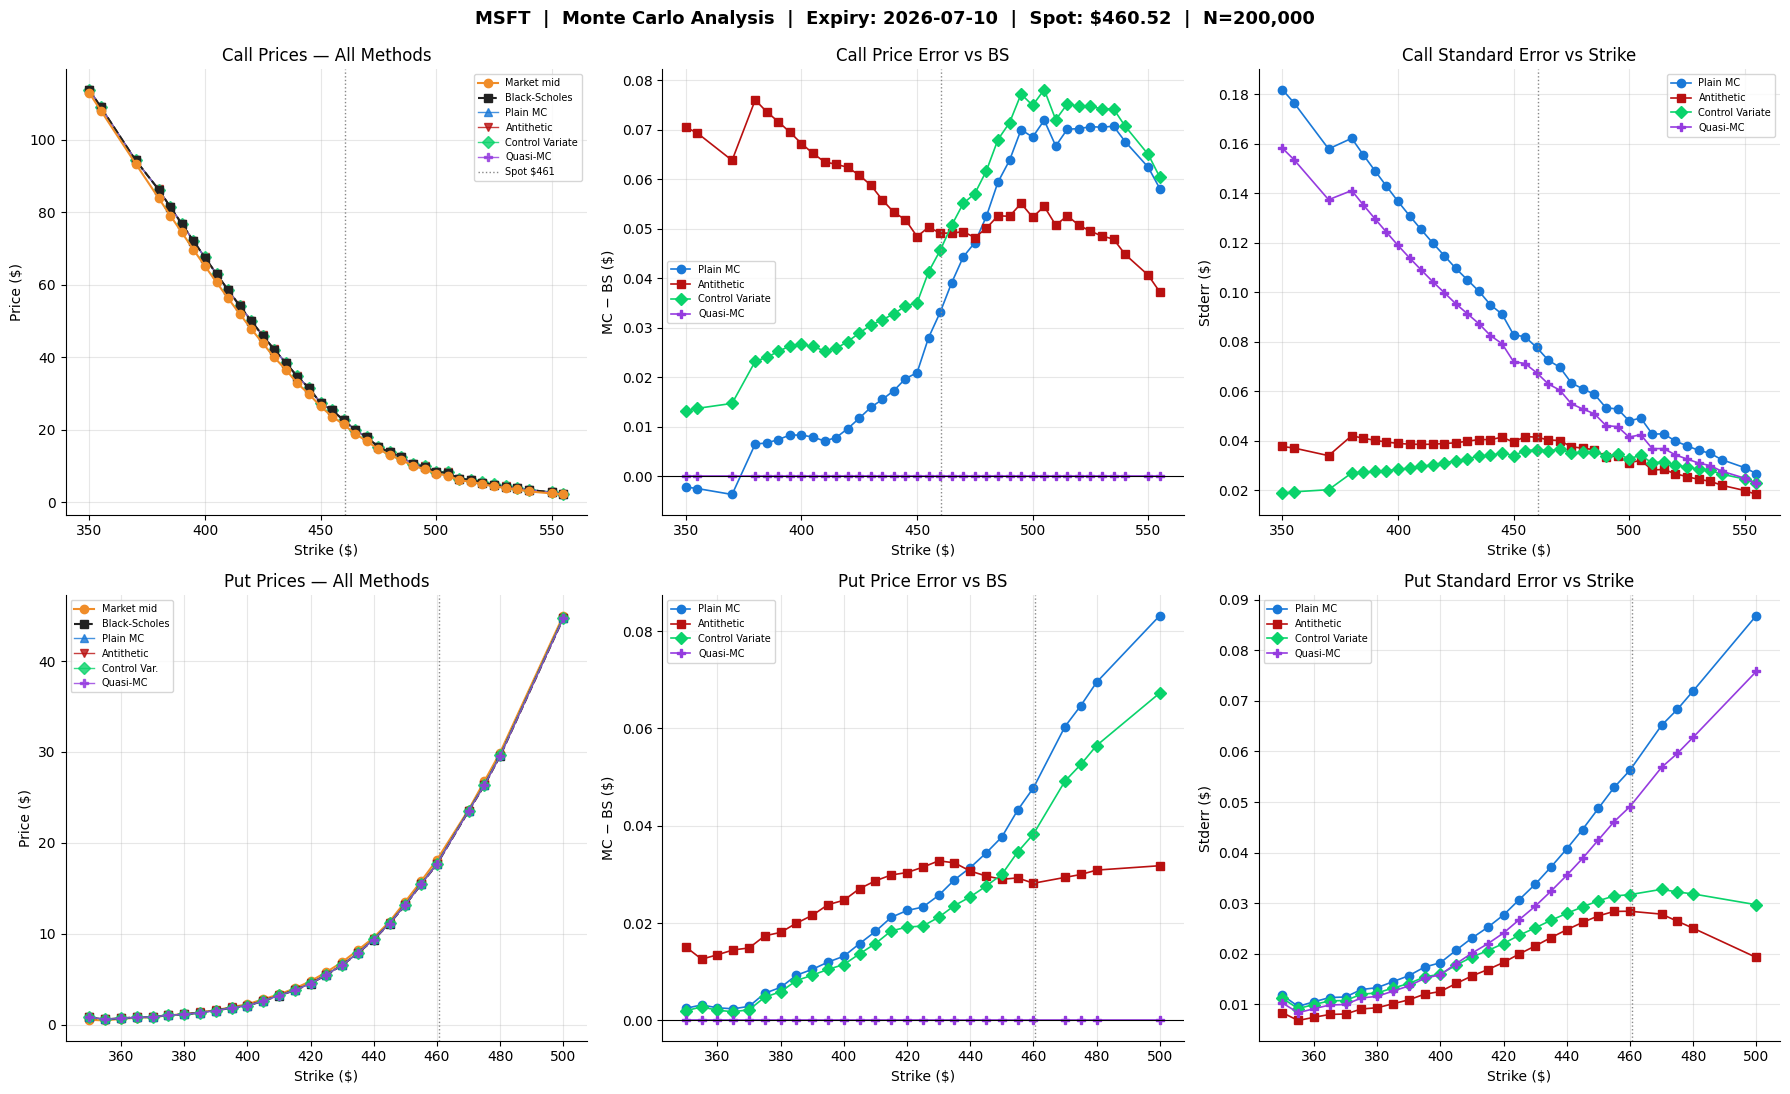

Saved: data/MSFT_2026-07-10_20260602_0214_mc_dashboard.png


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"{TICKER}  |  Monte Carlo Analysis  |  Expiry: {EXPIRY}  "
    f"|  Spot: ${S:.2f}  |  N={N_PATHS:,}",
    fontsize=13, fontweight='bold', y=0.99
)

# ── Row 0: Calls ──────────────────────────────────────────────────────────────
c = calls_mc.dropna(subset=['plain_price'])

# 0,0 — call prices: market, BS, all MC methods
ax = axes[0, 0]
ax.plot(c['strike'], c['market_mid'],  'o-',  color=COLORS['market'],          lw=1.5, label='Market mid',      zorder=5)
ax.plot(c['strike'], c['bs_price'],    's--', color=COLORS['bs'],              lw=1.5, label='Black-Scholes',   zorder=4)
ax.plot(c['strike'], c['plain_price'], '^-',  color=COLORS['plain_mc'],        lw=1,   label='Plain MC',        alpha=0.8)
ax.plot(c['strike'], c['anti_price'],  'v-',  color=COLORS['antithetic_mc'],   lw=1,   label='Antithetic',      alpha=0.8)
ax.plot(c['strike'], c['cv_price'],    'D-',  color=COLORS['control_variate'], lw=1,   label='Control Variate', alpha=0.8)
ax.plot(c['strike'], c['qmc_price'],   'P-',  color=COLORS['quasi_mc'],        lw=1,   label='Quasi-MC',        alpha=0.8)
ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':', label=f'Spot ${S:.0f}')
ax.set_title('Call Prices — All Methods'); ax.set_xlabel('Strike ($)'); ax.set_ylabel('Price ($)')
ax.legend(fontsize=7)

# 0,1 — call price errors vs BS
ax = axes[0, 1]
ax.plot(c['strike'], c['plain_err_bs'], 'o-',  color=COLORS['plain_mc'],        lw=1.2, label='Plain MC')
ax.plot(c['strike'], c['anti_err_bs'],  's-',  color=COLORS['antithetic_mc'],   lw=1.2, label='Antithetic')
ax.plot(c['strike'], c['cv_err_bs'],    'D-',  color=COLORS['control_variate'], lw=1.2, label='Control Variate')
ax.plot(c['strike'], c['qmc_err_bs'],   'P-',  color=COLORS['quasi_mc'],        lw=1.2, label='Quasi-MC')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
ax.set_title('Call Price Error vs BS'); ax.set_xlabel('Strike ($)'); ax.set_ylabel('MC − BS ($)')
ax.legend(fontsize=7)

# 0,2 — call standard errors (stderr per method)
ax = axes[0, 2]
ax.plot(c['strike'], c['plain_stderr'], 'o-',  color=COLORS['plain_mc'],        lw=1.2, label='Plain MC')
ax.plot(c['strike'], c['anti_stderr'],  's-',  color=COLORS['antithetic_mc'],   lw=1.2, label='Antithetic')
ax.plot(c['strike'], c['cv_stderr'],    'D-',  color=COLORS['control_variate'], lw=1.2, label='Control Variate')
ax.plot(c['strike'], c['qmc_stderr'],   'P-',  color=COLORS['quasi_mc'],        lw=1.2, label='Quasi-MC')
ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
ax.set_title('Call Standard Error vs Strike'); ax.set_xlabel('Strike ($)'); ax.set_ylabel('Stderr ($)')
ax.legend(fontsize=7)

# ── Row 1: Puts ──────────────────────────────────────────────────────────────
p = puts_mc.dropna(subset=['plain_price'])

ax = axes[1, 0]
ax.plot(p['strike'], p['market_mid'],  'o-',  color=COLORS['market'],          lw=1.5, label='Market mid')
ax.plot(p['strike'], p['bs_price'],    's--', color=COLORS['bs'],              lw=1.5, label='Black-Scholes')
ax.plot(p['strike'], p['plain_price'], '^-',  color=COLORS['plain_mc'],        lw=1,   label='Plain MC',      alpha=0.8)
ax.plot(p['strike'], p['anti_price'],  'v-',  color=COLORS['antithetic_mc'],   lw=1,   label='Antithetic',    alpha=0.8)
ax.plot(p['strike'], p['cv_price'],    'D-',  color=COLORS['control_variate'], lw=1,   label='Control Var.', alpha=0.8)
ax.plot(p['strike'], p['qmc_price'],   'P-',  color=COLORS['quasi_mc'],        lw=1,   label='Quasi-MC',      alpha=0.8)
ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
ax.set_title('Put Prices — All Methods'); ax.set_xlabel('Strike ($)'); ax.set_ylabel('Price ($)')
ax.legend(fontsize=7)

ax = axes[1, 1]
ax.plot(p['strike'], p['plain_err_bs'], 'o-',  color=COLORS['plain_mc'],        lw=1.2, label='Plain MC')
ax.plot(p['strike'], p['anti_err_bs'],  's-',  color=COLORS['antithetic_mc'],   lw=1.2, label='Antithetic')
ax.plot(p['strike'], p['cv_err_bs'],    'D-',  color=COLORS['control_variate'], lw=1.2, label='Control Variate')
ax.plot(p['strike'], p['qmc_err_bs'],   'P-',  color=COLORS['quasi_mc'],        lw=1.2, label='Quasi-MC')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
ax.set_title('Put Price Error vs BS'); ax.set_xlabel('Strike ($)'); ax.set_ylabel('MC − BS ($)')
ax.legend(fontsize=7)

ax = axes[1, 2]
ax.plot(p['strike'], p['plain_stderr'], 'o-',  color=COLORS['plain_mc'],        lw=1.2, label='Plain MC')
ax.plot(p['strike'], p['anti_stderr'],  's-',  color=COLORS['antithetic_mc'],   lw=1.2, label='Antithetic')
ax.plot(p['strike'], p['cv_stderr'],    'D-',  color=COLORS['control_variate'], lw=1.2, label='Control Variate')
ax.plot(p['strike'], p['qmc_stderr'],   'P-',  color=COLORS['quasi_mc'],        lw=1.2, label='Quasi-MC')
ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
ax.set_title('Put Standard Error vs Strike'); ax.set_xlabel('Strike ($)'); ax.set_ylabel('Stderr ($)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_mc_dashboard.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: data/{SLUG}_mc_dashboard.png")

## 9. Convergence Study

The core theoretical comparison: how fast does each method's error shrink as N grows?

- Plain MC: should track the **O(1/√N)** reference slope on a log-log plot
- Antithetic: same slope, lower intercept
- Control Variate: same slope, much lower intercept
- Quasi-MC: should track closer to **O(1/N)** — a steeper slope

Run on the ATM strike — this is where variance reduction is most effective and the theoretical slopes are clearest.

In [41]:
# ATM params (reuse from cell 4)
print(f"Convergence study on ATM call: K={K_atm}, σ={sigma_atm:.2%}, BS ref={bs_ref:.4f}")
print(f"N range: {N_CONV_MIN:,} → {N_CONV_MAX:,}  ({N_CONV_PTS} points, {N_REPEATS} repeats each)")
print("This may take 30–90 seconds...\n")

n_grid = np.unique(np.logspace(
    np.log10(N_CONV_MIN), np.log10(N_CONV_MAX), N_CONV_PTS
).astype(int))

conv_methods = [
    ('plain_mc',        plainMC,             COLORS['plain_mc'],        'Plain MC',         'o-'),
    ('antithetic_mc',   antitheticMC,         COLORS['antithetic_mc'],   'Antithetic',       's-'),
    ('control_variate', controlMC,    COLORS['control_variate'], 'Control Variate',  'D-'),
    ('quasi_mc',        quasiMC,              COLORS['quasi_mc'],        'Quasi-MC (Sobol)', 'P-'),
]

conv_results = {}
for key, fn, color, label, marker in conv_methods:
    t0 = time.perf_counter()
    conv_results[key] = convergence(
        p_atm, fn, n_grid, bs_ref,
        option_type='call', q=Q,
        seed=SEED, n_repeats=N_REPEATS
    )
    print(f"  {label:<25} done in {time.perf_counter()-t0:.1f}s")

print("\nConvergence data collected.")

Convergence study on ATM call: K=460.0, σ=36.91%, BS ref=22.6394
N range: 100 → 500,000  (20 points, 15 repeats each)
This may take 30–90 seconds...

  Plain MC                  done in 0.4s
  Antithetic                done in 0.7s
  Control Variate           done in 0.6s
  Quasi-MC (Sobol)          done in 1.1s

Convergence data collected.


## 10. Convergence Plots

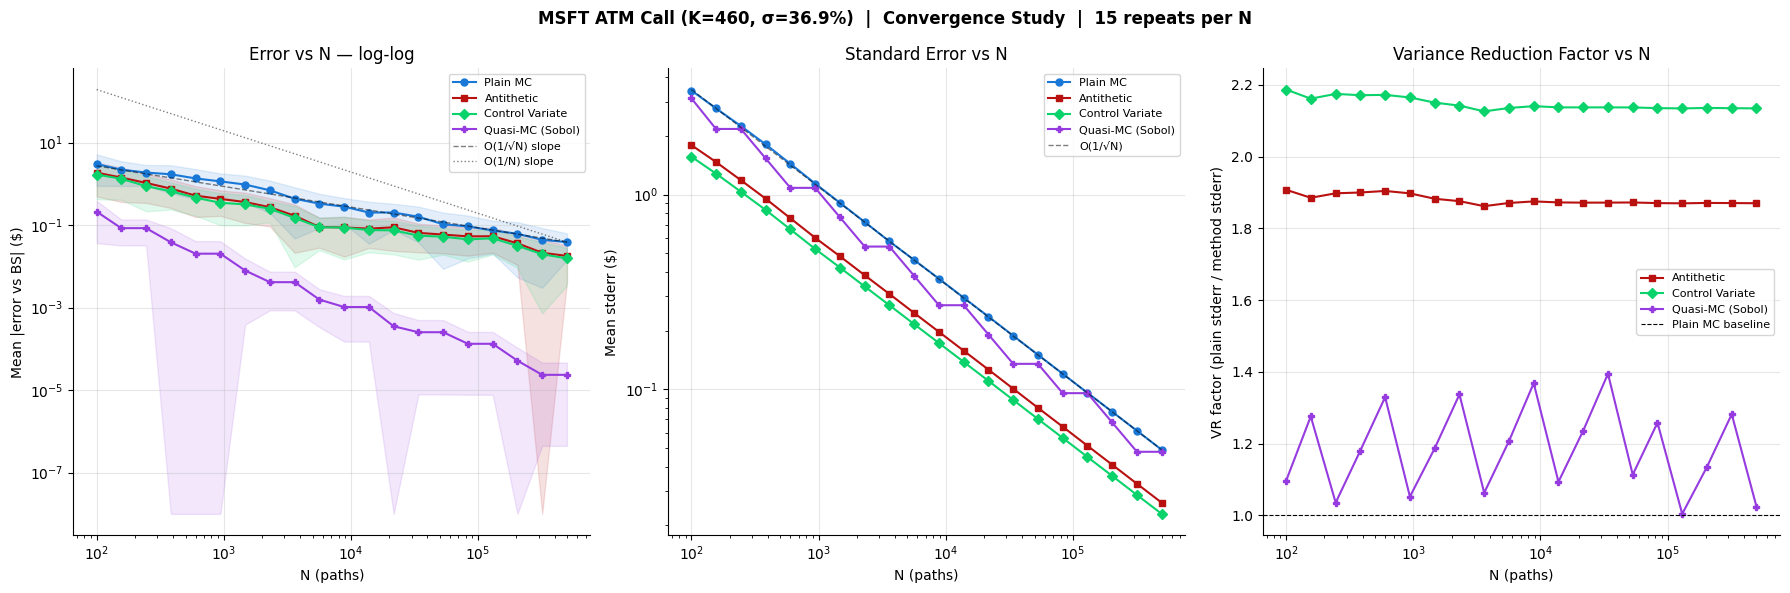

Saved: data/MSFT_2026-07-10_20260602_0214_mc_convergence.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f"{TICKER} ATM Call (K={K_atm:.0f}, σ={sigma_atm:.1%})  |  "
    f"Convergence Study  |  {N_REPEATS} repeats per N",
    fontsize=12, fontweight='bold'
)

# ── Plot 1: Error vs N (log-log) ──────────────────────────────────────────────
ax = axes[0]
for key, fn, color, label, marker in conv_methods:
    d = conv_results[key]
    ns = d['n_values']
    me = d['mean_error']
    se = d['std_error']
    mask = (ns > 0) & (me > 0)
    ax.loglog(ns[mask], me[mask], marker, color=color, lw=1.5, label=label, markersize=5)
    ax.fill_between(ns[mask],
        np.maximum(me[mask] - se[mask], 1e-8),
        me[mask] + se[mask],
        alpha=0.12, color=color)

# Reference slope lines
n_ref = np.array([n_grid[0], n_grid[-1]], dtype=float)
# Anchor both slopes at plain MC's largest-N error for visual alignment
plain_d   = conv_results['plain_mc']
anchor_n  = plain_d['n_values'][-1]
anchor_e  = plain_d['mean_error'][-1]
if anchor_e > 0 and anchor_n > 0:
    ax.loglog(n_ref, anchor_e * (anchor_n / n_ref)**0.5,
              'k--', lw=1, alpha=0.5, label='O(1/√N) slope')
    ax.loglog(n_ref, anchor_e * (anchor_n / n_ref)**1.0,
              'k:',  lw=1, alpha=0.5, label='O(1/N) slope')

ax.set_xlabel('N (paths)'); ax.set_ylabel('Mean |error vs BS| ($)')
ax.set_title('Error vs N — log-log'); ax.legend(fontsize=8)

# ── Plot 2: Stderr vs N ───────────────────────────────────────────────────────
ax = axes[1]
for key, fn, color, label, marker in conv_methods:
    d  = conv_results[key]
    ns = d['n_values']
    se = d['mean_stderr']
    mask = (ns > 0) & (se > 0)
    ax.loglog(ns[mask], se[mask], marker, color=color, lw=1.5, label=label, markersize=5)

# O(1/√N) reference
plain_se = conv_results['plain_mc']['mean_stderr']
if len(plain_se) > 0 and plain_se[-1] > 0:
    ax.loglog(n_ref,
              plain_se[-1] * (plain_d['n_values'][-1] / n_ref)**0.5,
              'k--', lw=1, alpha=0.5, label='O(1/√N)')

ax.set_xlabel('N (paths)'); ax.set_ylabel('Mean stderr ($)')
ax.set_title('Standard Error vs N'); ax.legend(fontsize=8)

# ── Plot 3: Variance Reduction Factor vs N ────────────────────────────────────
ax = axes[2]
plain_se_arr = conv_results['plain_mc']['mean_stderr']
plain_ns     = conv_results['plain_mc']['n_values']

for key, fn, color, label, marker in conv_methods[1:]:   # skip plain (VR=1)
    d       = conv_results[key]
    method_se = d['mean_stderr']
    # Align lengths (quasi-MC may have different n)
    min_len = min(len(plain_se_arr), len(method_se))
    vr = plain_se_arr[:min_len] / np.maximum(method_se[:min_len], 1e-12)
    ax.semilogx(plain_ns[:min_len], vr, marker, color=color, lw=1.5, label=label, markersize=5)

ax.axhline(1, color='black', lw=0.8, linestyle='--', label='Plain MC baseline')
ax.set_xlabel('N (paths)'); ax.set_ylabel('VR factor (plain stderr / method stderr)')
ax.set_title('Variance Reduction Factor vs N'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_mc_convergence.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: data/{SLUG}_mc_convergence.png")

## 11. Path Simulation Visualisation

Show what GBM paths actually look like — the simulation that underlies all four methods.

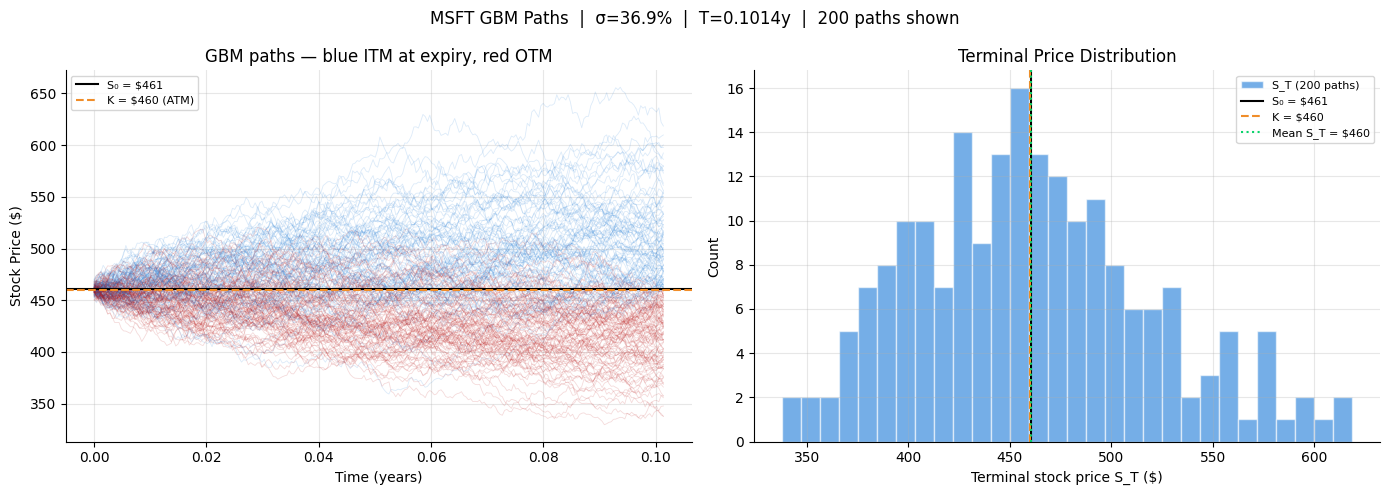

In [43]:
N_PATHS_PLOT = 200    # paths to draw
N_STEPS      = 252    # daily steps
rng          = np.random.default_rng(SEED)

dt      = T / N_STEPS
Z_paths = rng.standard_normal((N_PATHS_PLOT, N_STEPS))
log_ret = (sigma_atm**2) * (-0.5) * dt + sigma_atm * np.sqrt(dt) * Z_paths
log_S   = np.log(S) + np.cumsum(log_ret, axis=1)
S_paths = np.exp(log_S)

t_grid  = np.linspace(0, T, N_STEPS)
S_T_all = S_paths[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"{TICKER} GBM Paths  |  σ={sigma_atm:.1%}  |  T={T:.4f}y  |  {N_PATHS_PLOT} paths shown",
    fontsize=12
)

ax = axes[0]
for i in range(N_PATHS_PLOT):
    color = COLORS['plain_mc'] if S_paths[i, -1] > K_atm else COLORS['antithetic_mc']
    ax.plot(t_grid, S_paths[i], color=color, alpha=0.15, lw=0.6)
ax.axhline(S,     color='black',           lw=1.5, linestyle='-',  label=f'S₀ = ${S:.0f}')
ax.axhline(K_atm, color=COLORS['market'],  lw=1.5, linestyle='--', label=f'K = ${K_atm:.0f} (ATM)')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Stock Price ($)')
ax.set_title(f'GBM paths — blue ITM at expiry, red OTM')
ax.legend(fontsize=8)

# Terminal distribution
ax = axes[1]
ax.hist(S_T_all, bins=30, color=COLORS['plain_mc'], alpha=0.6, edgecolor='white',
        label=f'S_T ({N_PATHS_PLOT} paths)')
ax.axvline(S,           color='black',          lw=1.5, linestyle='-',  label=f'S₀ = ${S:.0f}')
ax.axvline(K_atm,       color=COLORS['market'], lw=1.5, linestyle='--', label=f'K = ${K_atm:.0f}')
ax.axvline(S_T_all.mean(), color=COLORS['control_variate'], lw=1.5, linestyle=':',
           label=f'Mean S_T = ${S_T_all.mean():.0f}')
ax.set_xlabel('Terminal stock price S_T ($)'); ax.set_ylabel('Count')
ax.set_title('Terminal Price Distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_mc_paths.png"), dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Results

In [44]:
calls_out = os.path.join(DATA_DIR, f"{SLUG}_mc_calls.csv")
puts_out  = os.path.join(DATA_DIR, f"{SLUG}_mc_puts.csv")
calls_mc.to_csv(calls_out, index=False)
puts_mc.to_csv(puts_out,   index=False)

# Save convergence arrays
conv_records = []
for key, fn, color, label, marker in conv_methods:
    d = conv_results[key]
    for i, n in enumerate(d['n_values']):
        conv_records.append({
            'method'     : label,
            'n_paths'    : int(n),
            'mean_error' : d['mean_error'][i]  if i < len(d['mean_error'])  else np.nan,
            'std_error'  : d['std_error'][i]   if i < len(d['std_error'])   else np.nan,
            'mean_stderr': d['mean_stderr'][i] if i < len(d['mean_stderr']) else np.nan,
        })
conv_df = pd.DataFrame(conv_records)
conv_out = os.path.join(DATA_DIR, f"{SLUG}_mc_convergence.csv")
conv_df.to_csv(conv_out, index=False)

print("Results saved:")
print(f"  {calls_out}")
print(f"  {puts_out}")
print(f"  {conv_out}")
print()
print("These files feed directly into the Quantum notebook for three-way comparison.")
print(f"\n  mc_calls = pd.read_csv('data/{SLUG}_mc_calls.csv')")
print(f"  mc_conv  = pd.read_csv('data/{SLUG}_mc_convergence.csv')")

Results saved:
  ./data/MSFT_2026-07-10_20260602_0214_mc_calls.csv
  ./data/MSFT_2026-07-10_20260602_0214_mc_puts.csv
  ./data/MSFT_2026-07-10_20260602_0214_mc_convergence.csv

These files feed directly into the Quantum notebook for three-way comparison.

  mc_calls = pd.read_csv('data/MSFT_2026-07-10_20260602_0214_mc_calls.csv')
  mc_conv  = pd.read_csv('data/MSFT_2026-07-10_20260602_0214_mc_convergence.csv')
